In [1]:
# ==========================================
# PYTORCH EXTRACTOR + SVM
# ==========================================
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from datasets import load_from_disk
import kagglehub
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import json



In [2]:
# 1. SETUP & DATA LOADING
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")
print(f"Using device: {device}")

print("Downloading dataset...")
path = kagglehub.dataset_download("phantrntngvyk64cntt/processed-rsitmd-256-clean")
hf_dataset = load_from_disk(path)

try:
    class_names = hf_dataset['train'].features['label'].names
except AttributeError:
    unique_labels = set(hf_dataset['train']['label'])
    class_names = [str(label) for label in sorted(unique_labels)]



Using device: cuda


100%|██████████| 491M/491M [00:06<00:00, 74.4MB/s]

Extracting files...


In [3]:
# 2. PREPROCESSING
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def transform_dataset(examples):
    # 1. Create the tensor versions of the images
    examples["pixel_values"] = [preprocess(img.convert("RGB")) for img in examples["image"]]

    # 2. Delete the raw PIL images so the DataLoader doesn't try to batch them
    del examples["image"]

    return examples

# Apply it exactly as before
hf_dataset.set_transform(transform_dataset)

print("Applying transformations dynamically...")

# Replace .map() and .set_format() with .set_transform()
hf_dataset.set_transform(transform_dataset)

# Your DataLoaders remain exactly the same
train_loader = DataLoader(hf_dataset["train"], batch_size=32, shuffle=True)
val_loader = DataLoader(hf_dataset["validation"], batch_size=32, shuffle=False)
test_loader = DataLoader(hf_dataset["test"], batch_size=32, shuffle=False)

Applying transformations dynamically...


In [4]:
# 3. BUILD EXTRACTOR
print("Building ResNet50 Extractor...")
extractor = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
extractor.fc = nn.Identity() # Remove the final layer!
extractor = extractor.to(device)
extractor.eval()

Building ResNet50 Extractor...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
# 4. EXTRACT FEATURES
def extract_features(dataloader, model_extractor):
    features_list, labels_list = [], []
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["pixel_values"].to(device)
            labels = batch["label"].numpy()
            features = model_extractor(inputs).cpu().numpy()
            features_list.append(features)
            labels_list.extend(labels)
    return np.vstack(features_list), np.array(labels_list)

print("Extracting features (this might take a minute)...")
X_train, y_train = extract_features(train_loader, extractor)
X_val, y_val = extract_features(val_loader, extractor)
X_test, y_test = extract_features(test_loader, extractor)

Extracting features (this might take a minute)...


In [6]:
# 5. TRAIN SVM
print("Training SVM...")
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

Training SVM...


SVC(probability=True, random_state=42)


Evaluating...
SVM Accuracy: 0.8555900621118012
Classification Report:
                    precision    recall  f1-score   support

          airport       0.61      0.78      0.68        18
         bareland       0.88      0.88      0.88         8
    baseballfield       1.00      0.57      0.73        14
            beach       0.88      1.00      0.93        21
             boat       0.00      0.00      0.00         2
           bridge       0.86      0.90      0.88        21
           center       0.93      0.70      0.80        20
           church       0.77      0.89      0.83        19
       commercial       0.79      0.75      0.77        20
 denseresidential       0.95      0.95      0.95        21
           desert       1.00      1.00      1.00        17
         farmland       0.96      0.96      0.96        24
           forest       1.00      0.94      0.97        16
       industrial       0.80      0.86      0.83        28
     intersection       0.00      0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


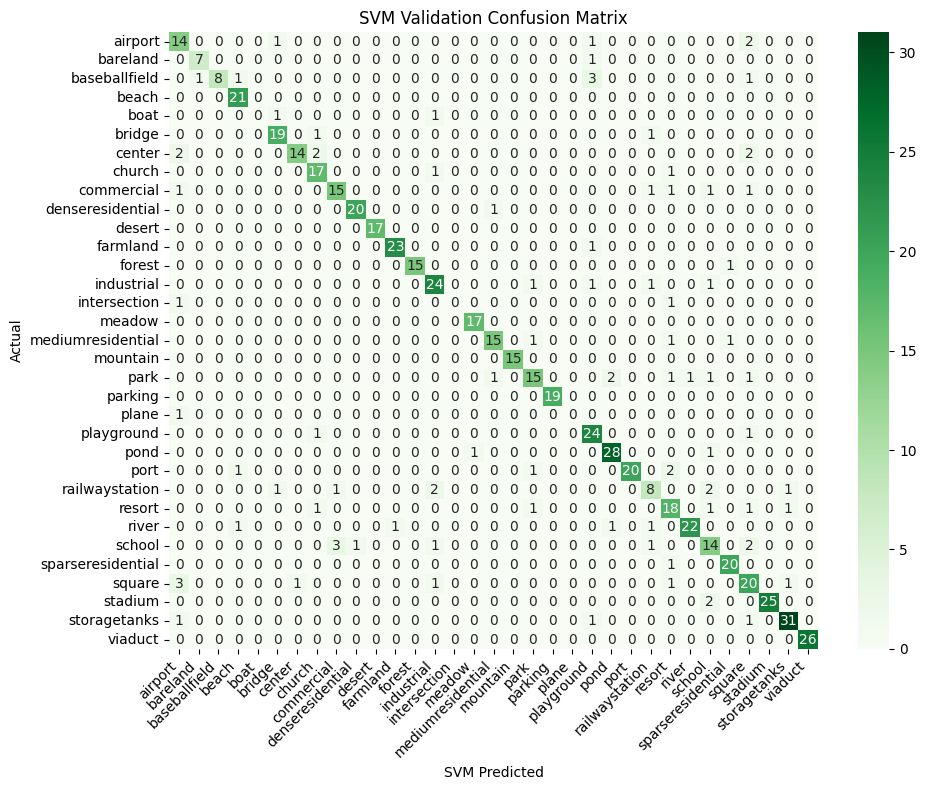

In [7]:
# 6. EVALUATION & CONFUSION MATRIX
print("\nEvaluating...")
y_pred = svm.predict(X_val)
print("SVM Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred, target_names=class_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('SVM Validation Confusion Matrix')
plt.xlabel('SVM Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [8]:
# 7. SAVE MODELS & METADATA
print("\nSaving deployable files...")
joblib.dump(svm, 'svm_model.joblib')
torch.save(extractor.state_dict(), "resnet50_extractor.pt")

with open("label_mapping.json", "w") as f:
    json.dump({"id2label": {int(i): name for i, name in enumerate(class_names)}}, f, indent=4)
print("✅ Saved: svm_model.joblib, resnet50_extractor.pt, label_mapping.json")


Saving deployable files...
✅ Saved: svm_model.joblib, resnet50_extractor.pt, label_mapping.json


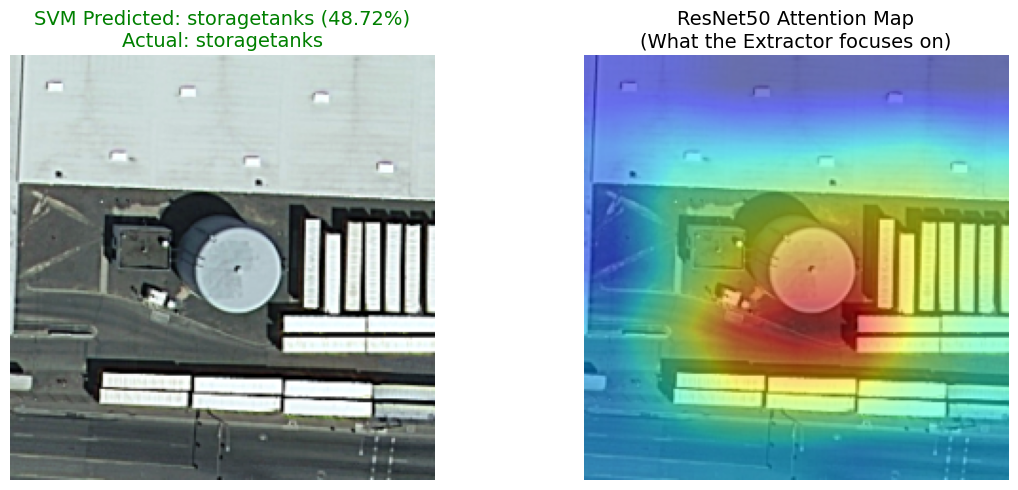

In [10]:
import torch.nn.functional as F

# ==========================================
# 8. TEST ON SINGLE IMAGE + FEATURE ATTENTION
# ==========================================
sample = hf_dataset['test'][450]
img_tensor = sample['pixel_values'].unsqueeze(0).to(device)
true_label_text = class_names[sample['label']]

# 1. Setup a Hook to eavesdrop on ResNet50's final layer
activations = []
def forward_hook(module, input, output):
    activations.append(output)

# Attach hook to the final convolutional block
target_layer = extractor.layer4[-1]
f_hook = target_layer.register_forward_hook(forward_hook)

# 2. Extract feature and predict with SVM
with torch.no_grad(): # No gradients needed!
    single_feature = extractor(img_tensor).cpu().numpy()

pred_idx = svm.predict(single_feature)[0]
pred_prob = np.max(svm.predict_proba(single_feature)) * 100
pred_class = class_names[pred_idx]

# 3. Process the generalized Feature Attention Map
# Take the mean of the feature maps across all channels to see general attention
captured_acts = activations[0]
heatmap = torch.mean(captured_acts, dim=1, keepdim=True)
heatmap = F.relu(heatmap) # Keep only positive attention

# Resize heatmap to match the 224x224 image
heatmap = F.interpolate(heatmap, size=(224, 224), mode='bilinear', align_corners=False)
heatmap = heatmap.squeeze().cpu().numpy()
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min()) # Normalize

f_hook.remove() # Clean up the hook

# 4. Un-normalize the tensor to restore the true colors of the original image
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
unnormalized_tensor = sample['pixel_values'].cpu() * std + mean
unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)
raw_image = transforms.ToPILImage()(unnormalized_tensor)

# ==========================================
# VISUALIZE BOTH IMAGES
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: True Original Image
plt.subplot(1, 2, 1)
plt.imshow(raw_image)
plt.title(f"SVM Predicted: {pred_class} ({pred_prob:.2f}%)\nActual: {true_label_text}",
          color='green' if pred_class == true_label_text else 'red', fontsize=14)
plt.axis('off')

# Plot 2: Extractor Attention Map
plt.subplot(1, 2, 2)
plt.imshow(raw_image)
plt.imshow(heatmap, cmap='jet', alpha=0.5) # Overlay the heatmap
plt.title("ResNet50 Attention Map\n(What the Extractor focuses on)", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()